Shape: (7043, 20)

Churn Distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64


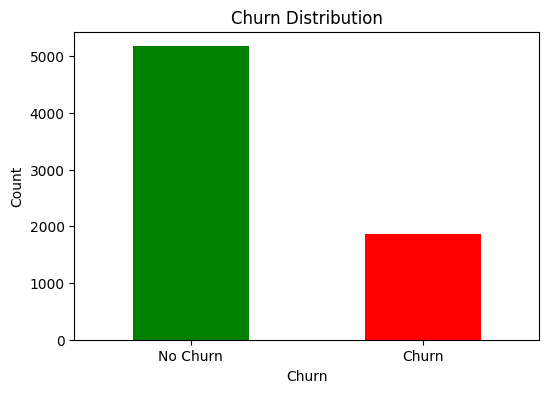

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset
df = pd.read_csv('../data/Churn Prediction Dataset.csv')

# Clean Data
df = df.drop('customerID', axis=1)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

print("Shape:", df.shape)
print("\nChurn Distribution:")
print(df['Churn'].value_counts())

# Plot Churn Distribution
plt.figure(figsize=(6,4))
df['Churn'].value_counts().plot(kind='bar', color=['green','red'])
plt.title('Churn Distribution')
plt.xticks([0,1], ['No Churn','Churn'], rotation=0)
plt.ylabel('Count')
plt.show()

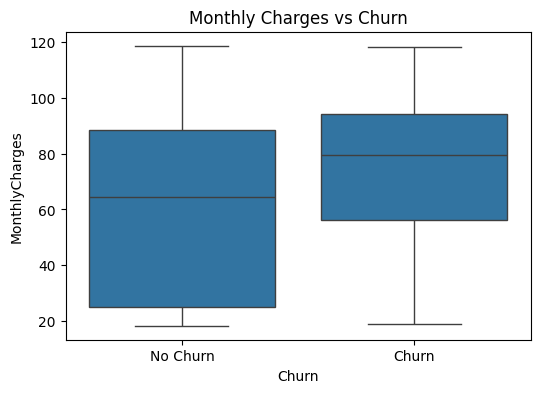

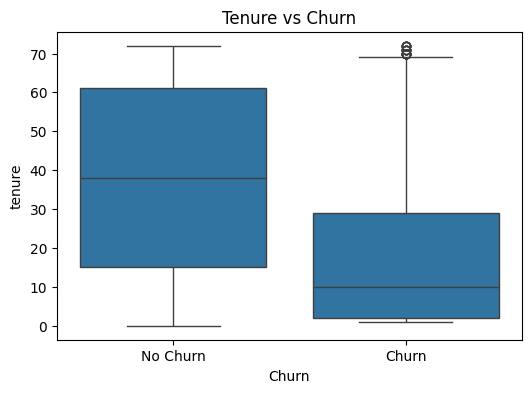

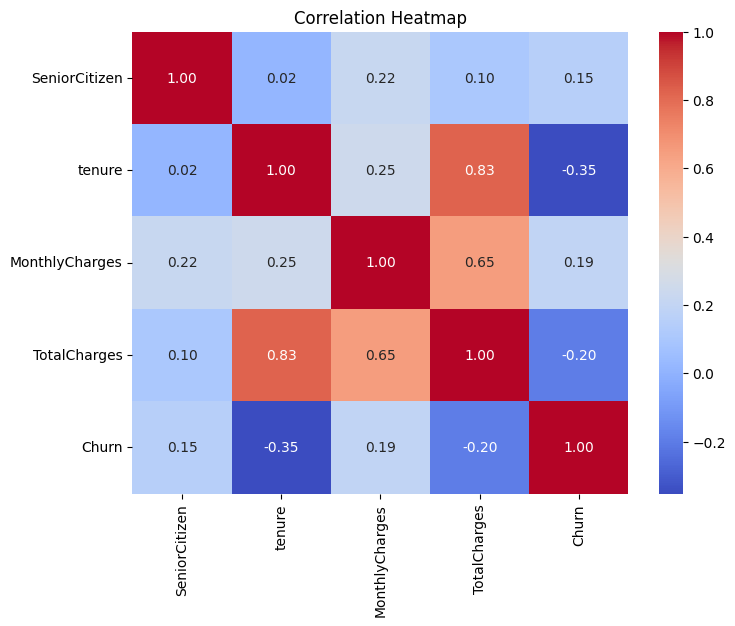

In [2]:
# Monthly Charges vs Churn
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title('Monthly Charges vs Churn')
plt.xticks([0,1], ['No Churn','Churn'])
plt.show()

# Tenure vs Churn
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title('Tenure vs Churn')
plt.xticks([0,1], ['No Churn','Churn'])
plt.show()

# Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.select_dtypes(include='number').corr(), 
            annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Encode categorical variables
le = LabelEncoder()
cat_cols = df.select_dtypes(include=['object', 'str']).columns.tolist()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# Features and target
X = df.drop(['Churn'], axis=1)
y = df['Churn']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
print("Train size:", X_train.shape, "| Test size:", X_test.shape)

Train size: (5634, 19) | Test size: (1409, 19)


=== Logistic Regression ===
Accuracy: 0.815471965933286
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.68      0.58      0.62       373

    accuracy                           0.82      1409
   macro avg       0.77      0.74      0.75      1409
weighted avg       0.81      0.82      0.81      1409



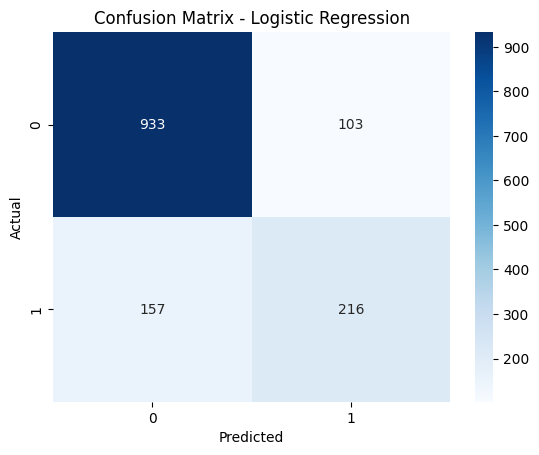

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.show()

====== SVM Results ======
Accuracy  : 0.8070
Precision : 0.6850
Recall    : 0.5013
F1-Score  : 0.5789


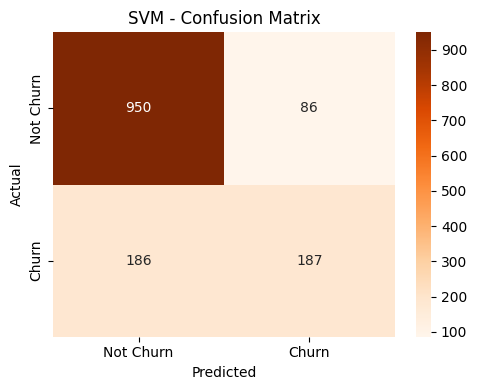

Confusion matrix saved to outputs folder.


In [5]:
# ============================================================
# STAGE: SVM (Support Vector Machine)
# ============================================================

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# --- Train SVM ---
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_model.fit(X_train, y_train)

# --- Predict ---
y_pred_svm = svm_model.predict(X_test)

# --- Evaluation Metrics ---
svm_accuracy  = accuracy_score(y_test, y_pred_svm)
svm_precision = precision_score(y_test, y_pred_svm)
svm_recall    = recall_score(y_test, y_pred_svm)
svm_f1        = f1_score(y_test, y_pred_svm)

print("====== SVM Results ======")
print(f"Accuracy  : {svm_accuracy:.4f}")
print(f"Precision : {svm_precision:.4f}")
print(f"Recall    : {svm_recall:.4f}")
print(f"F1-Score  : {svm_f1:.4f}")

# --- Confusion Matrix ---
cm_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Not Churn', 'Churn'],
            yticklabels=['Not Churn', 'Churn'])
plt.title('SVM - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('../outputs/svm_confusion_matrix.png', dpi=150)
plt.show()
print("Confusion matrix saved to outputs folder.")

====== Decision Tree Results ======
Accuracy : 0.7246
Precision: 0.4809
Recall   : 0.5067
F1-Score : 0.4935


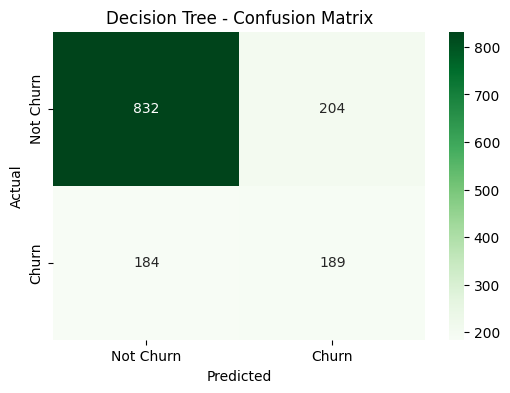

In [6]:
# Decision Tree Model
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import precision_score, recall_score, f1_score

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

print("====== Decision Tree Results ======")
print("Accuracy :", round(accuracy_score(y_test, dt_pred), 4))
print("Precision:", round(precision_score(y_test, dt_pred), 4))
print("Recall   :", round(recall_score(y_test, dt_pred), 4))
print("F1-Score :", round(f1_score(y_test, dt_pred), 4))

cm = confusion_matrix(y_test, dt_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Not Churn','Churn'],
            yticklabels=['Not Churn','Churn'])
plt.title('Decision Tree - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

====== Random Forest Results ======
Accuracy : 0.797
Precision: 0.6617
Recall   : 0.4772
F1-Score : 0.5545


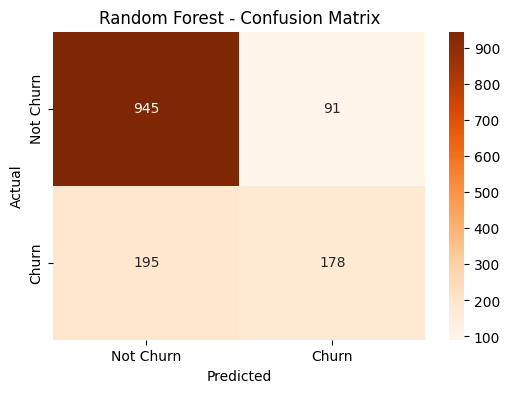

In [7]:
# Random Forest Model
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("====== Random Forest Results ======")
print("Accuracy :", round(accuracy_score(y_test, rf_pred), 4))
print("Precision:", round(precision_score(y_test, rf_pred), 4))
print("Recall   :", round(recall_score(y_test, rf_pred), 4))
print("F1-Score :", round(f1_score(y_test, rf_pred), 4))

cm = confusion_matrix(y_test, rf_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Not Churn','Churn'],
            yticklabels=['Not Churn','Churn'])
plt.title('Random Forest - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

KNN Accuracy: 75.73%

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.85      0.84      1036
           1       0.54      0.50      0.52       373

    accuracy                           0.76      1409
   macro avg       0.69      0.68      0.68      1409
weighted avg       0.75      0.76      0.75      1409



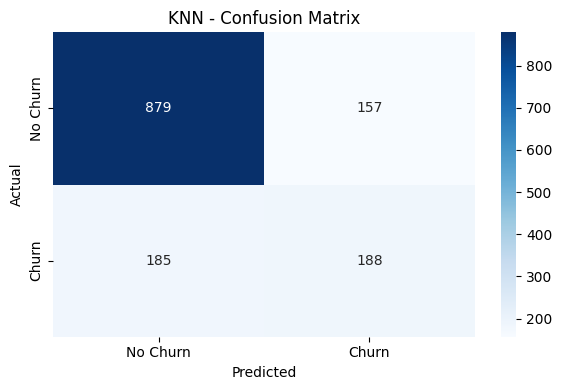

Confusion matrix saved to outputs folder.


In [8]:
# ============================================================
# KNN - K-Nearest Neighbors Classifier
# ============================================================

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# --- Train the model ---
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

# --- Predict ---
y_pred_knn = knn_model.predict(X_test)

# --- Accuracy & Report ---
knn_accuracy = accuracy_score(y_test, y_pred_knn)
print(f"KNN Accuracy: {knn_accuracy * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

# --- Confusion Matrix ---
cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('KNN - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('outputs/knn_confusion_matrix.png', dpi=150)
plt.show()
print("Confusion matrix saved to outputs folder.")

In [9]:
import os
os.makedirs('outputs', exist_ok=True)
print("✅ outputs folder created!")

✅ outputs folder created!


Gradient Boosting Accuracy: 80.55%

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1036
           1       0.67      0.52      0.59       373

    accuracy                           0.81      1409
   macro avg       0.76      0.71      0.73      1409
weighted avg       0.80      0.81      0.80      1409



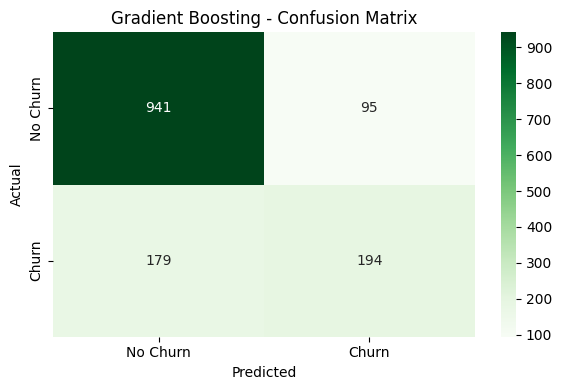

✅ Confusion matrix saved!


In [10]:
# ============================================================
# Gradient Boosting Classifier
# ============================================================

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# --- Train the model ---
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train)

# --- Predict ---
y_pred_gb = gb_model.predict(X_test)

# --- Accuracy & Report ---
gb_accuracy = accuracy_score(y_test, y_pred_gb)
print(f"Gradient Boosting Accuracy: {gb_accuracy * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb))

# --- Confusion Matrix ---
cm_gb = confusion_matrix(y_test, y_pred_gb)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_gb, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('Gradient Boosting - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('outputs/gb_confusion_matrix.png', dpi=150)
plt.show()
print("✅ Confusion matrix saved!")

In [11]:
# Install XGBoost (only need to do this once)
import subprocess
subprocess.run(['pip', 'install', 'xgboost'], capture_output=True)
print("✅ XGBoost ready!")

✅ XGBoost ready!


C:\Users\abarn\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\xgboost\training.py:200: UserWarning: [01:39:54] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 79.42%

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1036
           1       0.64      0.52      0.57       373

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.78      0.79      0.79      1409



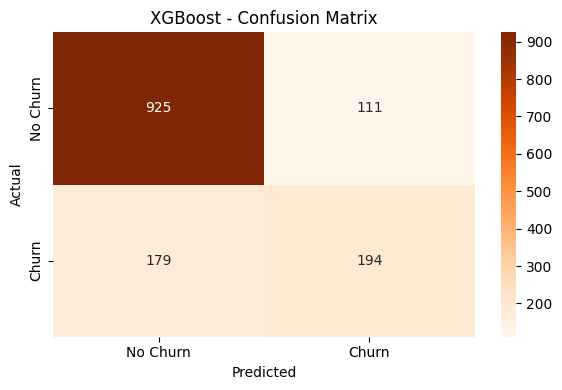

✅ Confusion matrix saved!


In [12]:
# ============================================================
# XGBoost Classifier
# ============================================================

from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# --- Train the model ---
xgb_model = XGBClassifier(n_estimators=100, random_state=42,
                           use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

# --- Predict ---
y_pred_xgb = xgb_model.predict(X_test)

# --- Accuracy & Report ---
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
print(f"XGBoost Accuracy: {xgb_accuracy * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

# --- Confusion Matrix ---
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('XGBoost - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('outputs/xgb_confusion_matrix.png', dpi=150)
plt.show()
print("✅ Confusion matrix saved!")

C:\Users\abarn\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


ANN Accuracy: 76.08%

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.86      0.84      1036
           1       0.56      0.48      0.52       373

    accuracy                           0.76      1409
   macro avg       0.69      0.67      0.68      1409
weighted avg       0.75      0.76      0.76      1409



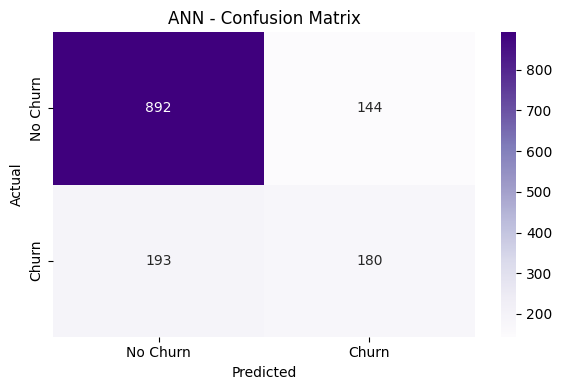

✅ Confusion matrix saved!


In [13]:
# ============================================================
# ANN - Artificial Neural Network
# ============================================================

from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# --- Train the model ---
ann_model = MLPClassifier(hidden_layer_sizes=(64, 32),
                           activation='relu',
                           max_iter=300,
                           random_state=42)
ann_model.fit(X_train, y_train)

# --- Predict ---
y_pred_ann = ann_model.predict(X_test)

# --- Accuracy & Report ---
ann_accuracy = accuracy_score(y_test, y_pred_ann)
print(f"ANN Accuracy: {ann_accuracy * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_ann))

# --- Confusion Matrix ---
cm_ann = confusion_matrix(y_test, y_pred_ann)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_ann, annot=True, fmt='d', cmap='Purples',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('ANN - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('outputs/ann_confusion_matrix.png', dpi=150)
plt.show()
print("✅ Confusion matrix saved!")

Training models...
  ✓ Logistic Regression trained


C:\Users\abarn\AppData\Local\Temp\ipykernel_12780\2801175380.py:26: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


  ✓ SVM trained
  ✓ Decision Tree trained
  ✓ Random Forest trained
  ✓ KNN trained
  ✓ Gradient Boosting trained
  ✓ XGBoost trained


C:\Users\abarn\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\xgboost\training.py:200: UserWarning: [01:40:20] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\abarn\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


  ✓ ANN trained


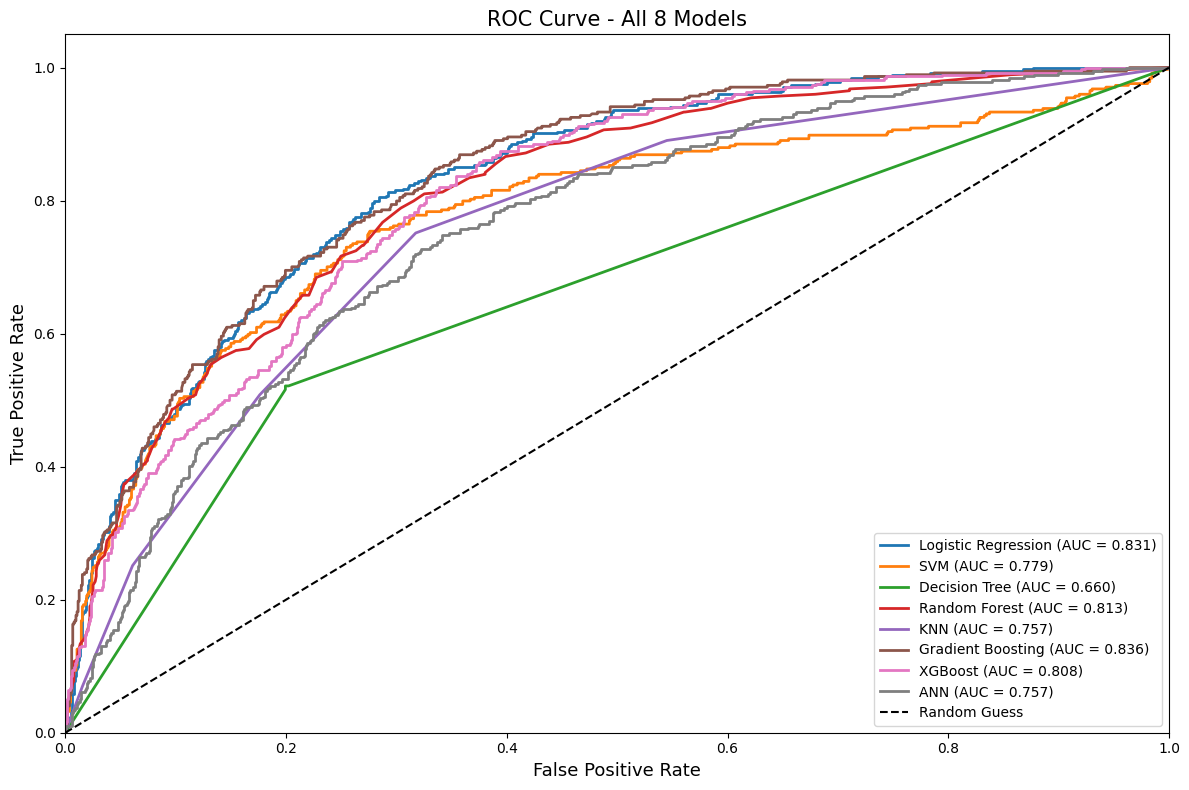

✅ ROC curve saved!


In [14]:
# ============================================================
# RETRAIN ALL 8 MODELS + ROC CURVE (All-in-One Cell)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import roc_curve, auc

# --- Load & Preprocess ---
df = pd.read_csv(r'../data/Churn Prediction Dataset.csv')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)
df.drop('customerID', axis=1, inplace=True)

le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

X = df.drop('Churn', axis=1)
y = df['Churn']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# --- Train All 8 Models ---
models_roc = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM":                 SVC(probability=True),
    "Decision Tree":       DecisionTreeClassifier(random_state=42),
    "Random Forest":       RandomForestClassifier(random_state=42),
    "KNN":                 KNeighborsClassifier(),
    "Gradient Boosting":   GradientBoostingClassifier(random_state=42),
    "XGBoost":             XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    "ANN":                 MLPClassifier(hidden_layer_sizes=(64,32), max_iter=300, random_state=42)
}

print("Training models...")
for name, model in models_roc.items():
    model.fit(X_train, y_train)
    print(f"  ✓ {name} trained")

# --- Plot ROC Curve ---
plt.figure(figsize=(12, 8))

for name, model in models_roc.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=13)
plt.ylabel('True Positive Rate', fontsize=13)
plt.title('ROC Curve - All 8 Models', fontsize=15)
plt.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.savefig('outputs/roc_curve_all_models.png', dpi=150)
plt.show()
print("✅ ROC curve saved!")

In [15]:
import os
print(os.getcwd())

C:\Users\abarn\OneDrive\Desktop\ChurnProject\notebooks


              Model  Accuracy  Precision  Recall  F1 Score
  Gradient Boosting     79.53      65.25   49.20     56.10
      Random Forest     79.18      64.31   48.66     55.40
                SVM     79.10      65.27   45.72     53.77
Logistic Regression     78.54      62.08   49.47     55.06
            XGBoost     76.40      56.52   48.66     52.30
                KNN     73.99      51.08   50.80     50.94
                ANN     73.99      51.11   49.20     50.14
      Decision Tree     72.64      48.63   52.14     50.32


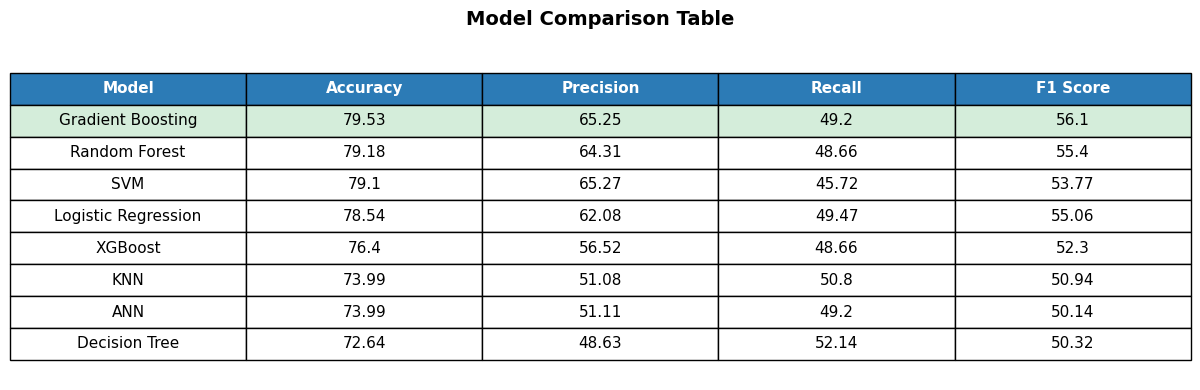

✅ Model comparison table saved!


In [16]:
# ============================================================
# FINAL MODEL COMPARISON TABLE
# ============================================================

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import matplotlib.pyplot as plt

results = []

for name, model in models_roc.items():
    y_pred = model.predict(X_test)
    results.append({
        "Model": name,
        "Accuracy":  round(accuracy_score(y_test, y_pred) * 100, 2),
        "Precision": round(precision_score(y_test, y_pred) * 100, 2),
        "Recall":    round(recall_score(y_test, y_pred) * 100, 2),
        "F1 Score":  round(f1_score(y_test, y_pred) * 100, 2)
    })

results_df = pd.DataFrame(results).sort_values("Accuracy", ascending=False).reset_index(drop=True)
print(results_df.to_string(index=False))

# --- Save as image ---
fig, ax = plt.subplots(figsize=(12, 4))
ax.axis('off')
table = ax.table(
    cellText=results_df.values,
    colLabels=results_df.columns,
    cellLoc='center',
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.8)

# Header row styling
for j in range(len(results_df.columns)):
    table[(0, j)].set_facecolor('#2c7bb6')
    table[(0, j)].set_text_props(color='white', fontweight='bold')

# Highlight best row (row 1)
for j in range(len(results_df.columns)):
    table[(1, j)].set_facecolor('#d4edda')

plt.title('Model Comparison Table', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('outputs/model_comparison_table.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Model comparison table saved!")

In [2]:
import os
print("=== ChurnProject/outputs/ ===")
print(os.listdir(r'../outputs'))

print("\n=== ChurnProject/notebooks/outputs/ ===")
print(os.listdir(r'outputs'))

=== ChurnProject/outputs/ ===
['svm_confusion_matrix.png']

=== ChurnProject/notebooks/outputs/ ===
['ann_confusion_matrix.png', 'confusion_matrix_ANN.png', 'confusion_matrix_Decision_Tree.png', 'confusion_matrix_Gradient_Boosting.png', 'confusion_matrix_KNN.png', 'confusion_matrix_Logistic_Regression.png', 'confusion_matrix_Random_Forest.png', 'confusion_matrix_SVM.png', 'confusion_matrix_XGBoost.png', 'gb_confusion_matrix.png', 'knn_confusion_matrix.png', 'model_comparison_table.png', 'roc_curve_all_models.png', 'xgb_confusion_matrix.png']
